In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.tools
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn import metrics

df = pd.read_csv('Life Expectancy Data.csv')

Next, we'll feature engineer the desired dataframe:

In [7]:
def weak_feature_engineering(df):
    r"""
    This function ingests the loaded dataframe and returns the dataframe with all feature engineering we desire.
    """
    df = df.copy()
    df = pd.get_dummies(df, columns = ['Region'], drop_first = True, prefix = 'from', dtype=float)
    df['log_GDP_per_capita'] = np.log1p(df['GDP_per_capita'])
    df = df.drop(columns=['Country',
                   'Infant_deaths',
                   'Under_five_deaths',
                   'Adult_mortality',
                   'Alcohol_consumption',
                   'Hepatitis_B',
                   'Measles',
                   'BMI',
                   'Polio',
                   'Diphtheria',
                   'Incidents_HIV',
                   'GDP_per_capita',
                   'Thinness_ten_nineteen_years',
                   'Thinness_five_nine_years',
                   'Economy_status_Developing'])
    return df

In [8]:
dfw = weak_feature_engineering(df)
dfw.head()

,Year,Population_mln,Schooling,Economy_status_Developed,Life_expectancy,from_Asia,from_Central America and Caribbean,from_European Union,from_Middle East,from_North America,from_Oceania,from_Rest of Europe,from_South America,log_GDP_per_capita
0,2015,78.53,7.8,0,76.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.306287
1,2015,46.44,9.7,1,82.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10.155918
2,2007,1183.21,5.0,0,65.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.981935
3,2006,0.75,7.9,0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.330140
4,2012,7.91,12.8,1,81.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,10.433998


---
# Train/test split

In [9]:
y = dfw['Life_expectancy']
X = dfw.drop(columns='Life_expectancy')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train: 2291   Test: 573   Features: 13


---
# Scaling

In [10]:
X_cols = X.columns.tolist()
X_train[X_cols].describe().loc[['min', 'max', 'mean', 'std']].T.round(1)

scalers = {'unscaled': None,
           'StandardScaler': StandardScaler(),
           'MinMaxScaler': MinMaxScaler(),
           'RobustScaler': RobustScaler()}

rows = []
for name, sc in scalers.items():
    Xtr, Xte = X_train.copy().astype(float), X_test.copy().astype(float)

    if sc is not None:
        Xtr[X_cols] = sc.fit_transform(Xtr[X_cols])   # fit on TRAIN only
        Xte[X_cols] = sc.transform(Xte[X_cols])

    lr = LinearRegression().fit(Xtr, y_train)
    pred = lr.predict(Xte)

    # condition number of the same design matrix, via StatsModels
    cond = sm.OLS(y_train, sm.add_constant(Xtr, has_constant='add')).fit().condition_number

    rows.append([name,
                 metrics.r2_score(y_test, pred),
                 metrics.root_mean_squared_error(y_test, pred),
                 metrics.mean_absolute_error(y_test, pred),
                 cond])

scaler_comparison = pd.DataFrame(rows, columns=['scaler', 'r2', 'rmse', 'mae', 'condition_no'])
scaler_comparison.round(6)

,scaler,r2,rmse,mae,condition_no
0,unscaled,0.750749,4.548147,3.303898,890117.403271
1,StandardScaler,0.750749,4.548147,3.303898,5.396070
2,MinMaxScaler,0.750749,4.548147,3.303898,16.276566
3,RobustScaler,0.750749,4.548147,3.303898,66.132365


In [11]:
scaler = StandardScaler()

X_train_s = X_train.copy().astype(float)
X_test_s  = X_test.copy().astype(float)
X_train_s[X_cols] = scaler.fit_transform(X_train_s[X_cols])
X_test_s[X_cols]  = scaler.transform(X_test_s[X_cols])

In [12]:
def fit_ols(Xtr, ytr, Xte):
    """Add the constant, fit, and return the results object plus train/test predictions."""
    Xtr = sm.add_constant(Xtr.astype(float), has_constant='add')
    Xte = sm.add_constant(Xte.astype(float), has_constant='add')[Xtr.columns]
    res = sm.OLS(ytr, Xtr).fit()
    return res, res.predict(Xtr), res.predict(Xte)

res_full, ptr_full, pte_full = fit_ols(X_train_s, y_train, X_test_s)
print('Train R-squared      :', round(res_full.rsquared, 4))
print('Adjusted R-squared   :', round(res_full.rsquared_adj, 4))
print('Condition number     : %.4g' % res_full.condition_number)

Train R-squared      : 0.7986
Adjusted R-squared   : 0.7974
Condition number     : 5.396


In [13]:
design = sm.add_constant(X_train_s.astype(float), has_constant='add')
print('columns:', design.shape[1], ' rank:', np.linalg.matrix_rank(design.values))

columns: 14  rank: 14


In [14]:
Xv = sm.add_constant(X_train_s[X_cols].astype(float), has_constant='add')

vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns)

vif.drop('const').sort_values(ascending=False).round(2)


Economy_status_Developed              5.34
from_European Union                   4.77
log_GDP_per_capita                    3.85
Schooling                             3.81
from_Rest of Europe                   1.91
from_Asia                             1.64
from_Middle East                      1.55
from_Central America and Caribbean    1.54
from_South America                    1.42
from_North America                    1.33
from_Oceania                          1.32
Population_mln                        1.13
Year                                  1.06
dtype: float64

In [15]:
c = X_train.corr()
pairs = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack()
pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False)

Economy_status_Developed  from_European Union    0.821563
Schooling                 log_GDP_per_capita     0.780728
dtype: float64

In [16]:
rmse = metrics.root_mean_squared_error(y_test, pte_full)
mae  = metrics.mean_absolute_error(y_test, pte_full)
r2   = metrics.r2_score(y_test, pte_full)

print(f'RMSE : {rmse:.3f}')
print(f'MAE  : {mae:.3f}')
print(f'R²   : {r2:.3f}')

RMSE : 4.548
MAE  : 3.304
R²   : 0.751


Median absolute error : 2.2999222978716887
Mean absolute error   : 3.3038980381090606
RMSE                  : 4.548147361993363

Five largest absolute errors:
[14. 15. 16. 17. 17.]


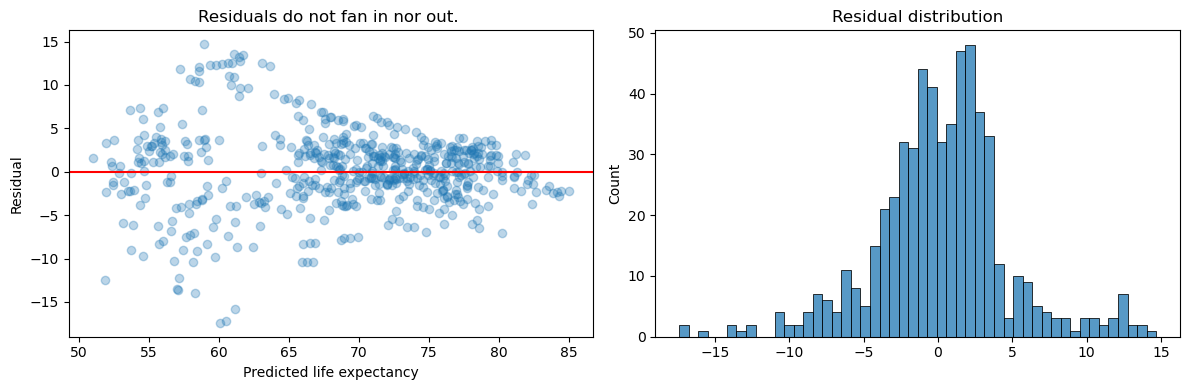

In [21]:
errors = y_test - pte_full

print(f'Median absolute error : {np.median(np.abs(errors))}')
print(f'Mean absolute error   : {np.mean(np.abs(errors))}')
print(f'RMSE                  : {metrics.root_mean_squared_error(y_test, pte_full)}')
print()
print('Five largest absolute errors:')
print(np.sort(np.abs(errors))[-5:].round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pte_full, errors, alpha=0.3)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predicted life expectancy'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals do not fan in nor out. ')
sns.histplot(errors, bins=50, ax=axes[1]).set_title('Residual distribution')
plt.tight_layout(); plt.show()

There is heteroscedascity here! To try and fix this, let me see if refitting it to log(`Life_expectancy`) is better here

In [37]:
def all_metrics(y_true, y_pred, label):
    return {
        'model': label,
        'R2':    metrics.r2_score(y_true, y_pred),
        'RMSE':  metrics.root_mean_squared_error(y_true, y_pred),
        'MAE':   metrics.mean_absolute_error(y_true, y_pred),
        'MAPE%': metrics.mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

res_log, ptr_log, pte_log = fit_ols(X_train, np.log(y_train), X_test)

pred_life = np.exp(pte_log)

log_model = all_metrics(y_test, pred_life, 'OLS on log(LifeExp)')

comparison = pd.DataFrame([all_metrics(y_test, pte_full, 'OLS on LifeExp'), log_model])
comparison.round(4)

,model,R2,RMSE,MAE,MAPE%
0,OLS on LifeExp,0.7507,4.5481,3.3039,5.1601
1,OLS on log(LifeExp),0.7403,4.6422,3.3872,5.2398


In [38]:
def all_metrics(y_true, y_pred, label):
    return {
        'model': label,
        'R2':    metrics.r2_score(y_true, y_pred),
        'RMSE':  metrics.root_mean_squared_error(y_true, y_pred),
        'MAE':   metrics.mean_absolute_error(y_true, y_pred),
        'MAPE%': metrics.mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

res_log, ptr_log, pte_log = fit_ols(X_train, np.sqrt(y_train), X_test)

pred_life = np.square(pte_log)

log_model = all_metrics(y_test, pred_life, 'OLS on sqrt(LifeExp)')

comparison = pd.DataFrame([all_metrics(y_test, pte_full, 'OLS on LifeExp'), log_model])
comparison.round(4)

,model,R2,RMSE,MAE,MAPE%
0,OLS on LifeExp,0.7507,4.5481,3.3039,5.1601
1,OLS on sqrt(LifeExp),0.7465,4.5871,3.3397,5.1923


In [39]:
def all_metrics(y_true, y_pred, label):
    return {
        'model': label,
        'R2':    metrics.r2_score(y_true, y_pred),
        'RMSE':  metrics.root_mean_squared_error(y_true, y_pred),
        'MAE':   metrics.mean_absolute_error(y_true, y_pred),
        'MAPE%': metrics.mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

res_log, ptr_log, pte_log = fit_ols(X_train, np.reciprocal(y_train), X_test)

pred_life = np.reciprocal(pte_log)

log_model = all_metrics(y_test, pred_life, 'OLS on 1/LifeExp)')

comparison = pd.DataFrame([all_metrics(y_test, pte_full, 'OLS on LifeExp'), log_model])
comparison.round(4)

,model,R2,RMSE,MAE,MAPE%
0,OLS on LifeExp,0.7507,4.5481,3.3039,5.1601
1,OLS on 1/LifeExp),0.7203,4.8180,3.5334,5.4035


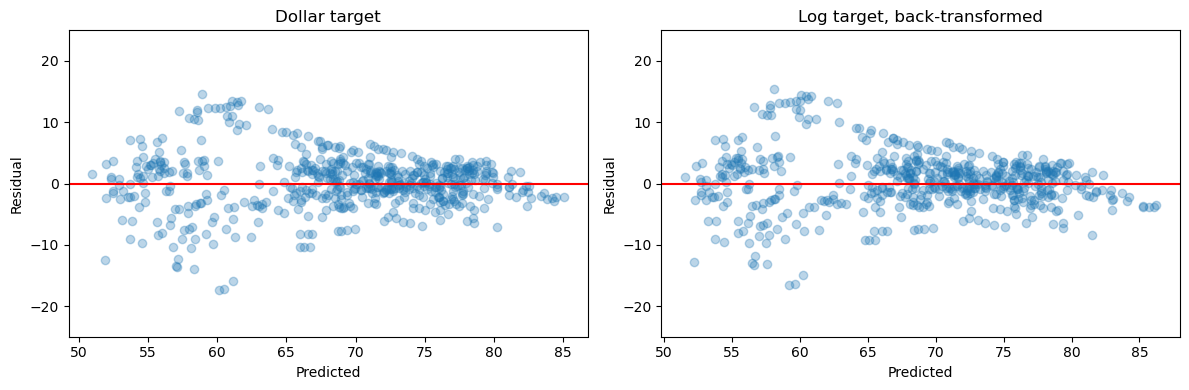

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pte_full, y_test - pte_full, alpha=0.3)
axes[0].axhline(0, color='red'); axes[0].set_title('Dollar target')
axes[1].scatter(pred_dollars, y_test - pred_dollars, alpha=0.3)
axes[1].axhline(0, color='red'); axes[1].set_title('Log target, back-transformed')
for a in axes:
    a.set_xlabel('Predicted'); a.set_ylabel('Residual'); a.set_ylim(-25, 25)
plt.tight_layout(); plt.show()

---
# Final model

In [45]:
X_train.columns

Index(['Year', 'Population_mln', 'Schooling', 'Economy_status_Developed',
       'from_Asia', 'from_Central America and Caribbean',
       'from_European Union', 'from_Middle East', 'from_North America',
       'from_Oceania', 'from_Rest of Europe', 'from_South America',
       'log_GDP_per_capita'],
      dtype='object')

In [44]:
final = res_full

print('FINAL MODEL: OLS on Life_Expectancy, StandardScaler, 13 features + constant\n')
print(f'{"":8s} {"MAPE":>8s} {"MAE":>12s} {"RMSE":>12s} {"R2":>8s}')
for label, yt, yp in [('Train', y_train, ptr_full), ('Test', y_test, pte_full)]:
    print(f'{label:8s} '
          f'{metrics.mean_absolute_percentage_error(yt, yp)*100:7.2f}% '
          f'{metrics.mean_absolute_error(yt, yp):12,.0f} '
          f'{metrics.root_mean_squared_error(yt, yp):12,.0f} '
          f'{metrics.r2_score(yt, yp):8.4f}')

FINAL MODEL: OLS on Life_Expectancy, StandardScaler, 13 features + constant

             MAPE          MAE         RMSE       R2
Train       4.88%            3            4   0.7986
Test        5.16%            3            5   0.7507


In [46]:
coefs = final.params.drop('const')

# The largest raw coefficients are all zoning dummies, whose reference category
# is a handful of agricultural plots - large, but not the interesting story.
print('Largest coefficients overall:')
print(coefs.sort_values(key=abs, ascending=False).head(6).round(3))

print('\nThe features the client actually cares about:')
print(coefs[['Year', 'Population_mln', 'Schooling', 'Economy_status_Developed',
       'from_Asia', 'from_Central America and Caribbean',
       'from_European Union', 'from_Middle East', 'from_North America',
       'from_Oceania', 'from_Rest of Europe', 'from_South America',
       'log_GDP_per_capita']].round(4))

Largest coefficients overall:
log_GDP_per_capita                    4.581
from_Asia                             3.211
from_European Union                   3.086
from_Central America and Caribbean    2.931
from_Rest of Europe                   2.856
from_South America                    2.499
dtype: float64

The features the client actually cares about:
Year                                  1.3029
Population_mln                        0.1163
Schooling                             0.2493
Economy_status_Developed              0.7553
from_Asia                             3.2106
from_Central America and Caribbean    2.9307
from_European Union                   3.0865
from_Middle East                      2.3550
from_North America                    1.1739
from_Oceania                          1.7858
from_Rest of Europe                   2.8562
from_South America                    2.4992
log_GDP_per_capita                    4.5808
dtype: float64
